# **Redes Neuronales:perceptron simple y multicapa(MLP)**



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# **El perceptrón simple desde cero**

In [2]:
class PerceptronSimple:
    def __init__(self, n_entradas, tasa_aprendizaje=0.1):
        self.pesos = np.zeros(n_entradas)
        self.sesgo = 0.0
        self.tasa_aprendizaje = tasa_aprendizaje

    def activacion(self, z):
        return 1 if z >= 0 else 0

    def predecir(self, x):
        z = np.dot(x, self.pesos) + self.sesgo
        return self.activacion(z)

    def entrenar(self, X, y, epocas=20):
        historial_errores = []
        for _ in range(epocas):
            errores = 0
            for xi, yi in zip(X, y):
                prediccion = self.predecir(xi)
                error = yi - prediccion
                if error != 0:
                    self.pesos += self.tasa_aprendizaje * error * xi
                    self.sesgo += self.tasa_aprendizaje * error
                    errores += 1
            historial_errores.append(errores)
        return historial_errores

*Aprendiendo la compuerta lógica AND*

In [3]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

perceptron_and = PerceptronSimple(n_entradas=2, tasa_aprendizaje=0.1)
errores_and = perceptron_and.entrenar(X_and, y_and, epocas=10)

print("Errores por época:", errores_and)
print("Pesos finales:", perceptron_and.pesos, " Sesgo final:", perceptron_and.sesgo)
for xi, yi in zip(X_and, y_and):
    print(f"  entrada={xi} -> predicción={perceptron_and.predecir(xi)} (real={yi})")

Errores por época: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0]
Pesos finales: [0.2 0.1]  Sesgo final: -0.20000000000000004
  entrada=[0 0] -> predicción=0 (real=0)
  entrada=[0 1] -> predicción=0 (real=0)
  entrada=[1 0] -> predicción=0 (real=0)
  entrada=[1 1] -> predicción=1 (real=1)


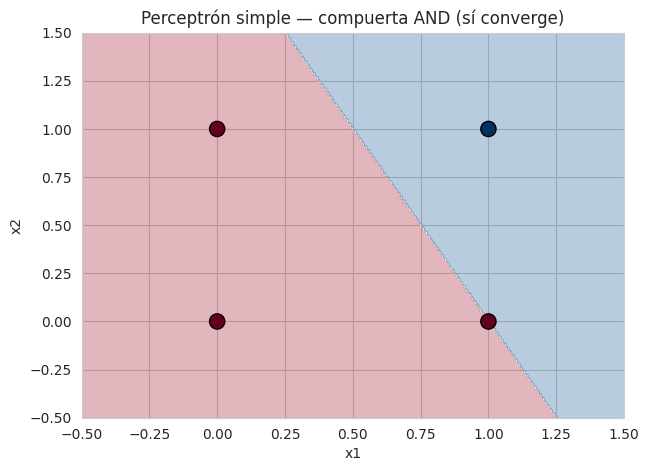

In [4]:
def graficar_frontera_decision(modelo, X, y, titulo, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = np.array([modelo.predecir(np.array([a, b])) for a, b in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=120)
    ax.set_title(titulo)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

graficar_frontera_decision(perceptron_and, X_and, y_and, "Perceptrón simple — compuerta AND (sí converge)")
plt.show()

*El problema XOR*

Errores por época: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


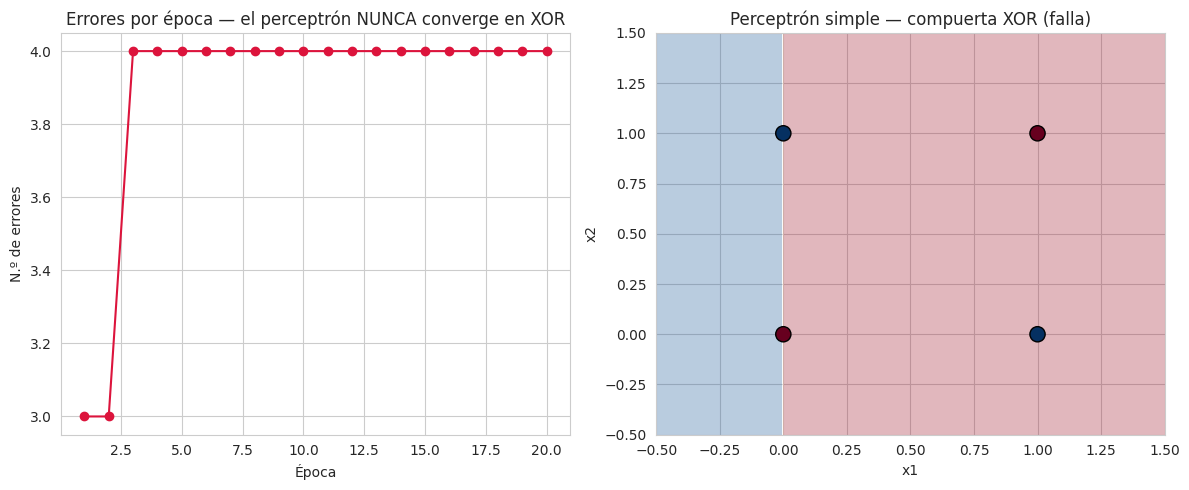

In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

perceptron_xor = PerceptronSimple(n_entradas=2, tasa_aprendizaje=0.1)
errores_xor = perceptron_xor.entrenar(X_xor, y_xor, epocas=20)

print("Errores por época:", errores_xor)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
ejes[0].plot(range(1, 21), errores_xor, marker="o", color="crimson")
ejes[0].set_title("Errores por época — el perceptrón NUNCA converge en XOR")
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("N.º de errores")

graficar_frontera_decision(perceptron_xor, X_xor, y_xor, "Perceptrón simple — compuerta XOR (falla)", ax=ejes[1])
plt.tight_layout()
plt.show()

# **El perceptrón Multicapa(MLP)**

In [6]:
X_xor_f = X_xor.astype("float32")
y_xor_f = y_xor.astype("float32")

modelo_mlp_xor = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh", name="capa_oculta"),
    layers.Dense(1, activation="sigmoid", name="salida"),
])
modelo_mlp_xor.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
                        loss="binary_crossentropy", metrics=["accuracy"])
modelo_mlp_xor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)             │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

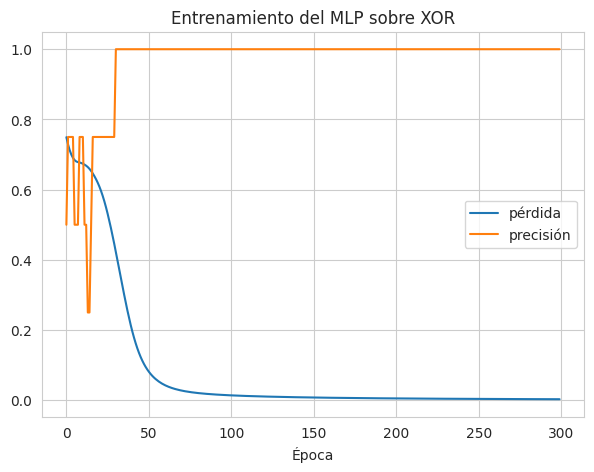

Predicciones finales:
  entrada=[0. 0.] -> probabilidad=0.000 -> clase=0 (real=0)
  entrada=[0. 1.] -> probabilidad=0.998 -> clase=1 (real=1)
  entrada=[1. 0.] -> probabilidad=0.995 -> clase=1 (real=1)
  entrada=[1. 1.] -> probabilidad=0.005 -> clase=0 (real=0)


In [7]:
historial = modelo_mlp_xor.fit(X_xor_f, y_xor_f, epochs=300, verbose=0)

plt.plot(historial.history["loss"], label="pérdida")
plt.plot(historial.history["accuracy"], label="precisión")
plt.title("Entrenamiento del MLP sobre XOR")
plt.xlabel("Época")
plt.legend()
plt.show()

print("Predicciones finales:")
for xi, yi in zip(X_xor_f, y_xor_f):
    pred = modelo_mlp_xor.predict(xi.reshape(1, -1), verbose=0)[0][0]
    print(f"  entrada={xi} -> probabilidad={pred:.3f} -> clase={round(pred)} (real={int(yi)})")

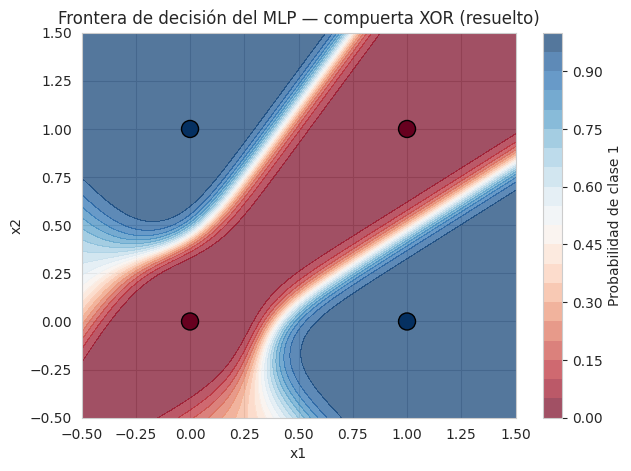

In [8]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")
Z = modelo_mlp_xor.predict(grid, verbose=0).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.7)
plt.colorbar(label="Probabilidad de clase 1")
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="RdBu", edgecolor="k", s=150)
plt.title("Frontera de decisión del MLP — compuerta XOR (resuelto)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

# **Por qué la no linealidad importa: funciones de activación**

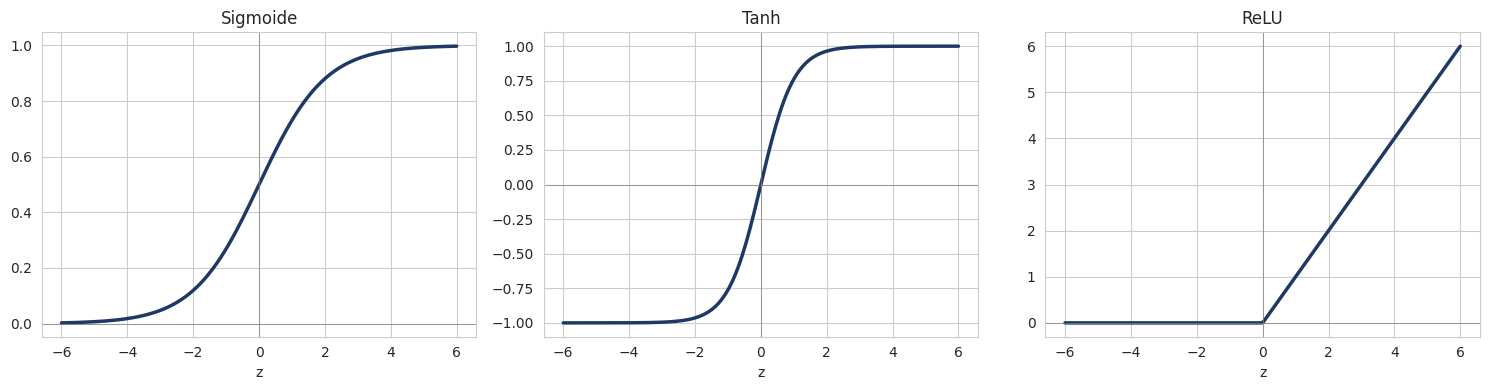

In [9]:
z = np.linspace(-6, 6, 200)
sigmoide = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for ax, funcion, nombre in zip(ejes, [sigmoide, tanh, relu], ["Sigmoide", "Tanh", "ReLU"]):
    ax.plot(z, funcion, linewidth=2.5, color="#1F3864")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_title(nombre)
    ax.set_xlabel("z")
plt.tight_layout()
plt.show()

# **MLP sobre un problema más realista: make moons**

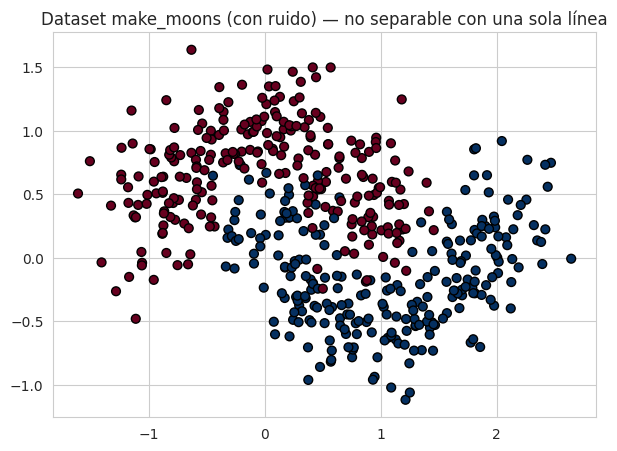

In [10]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k", s=40)
plt.title("Dataset make_moons (con ruido) — no separable con una sola línea")
plt.show()

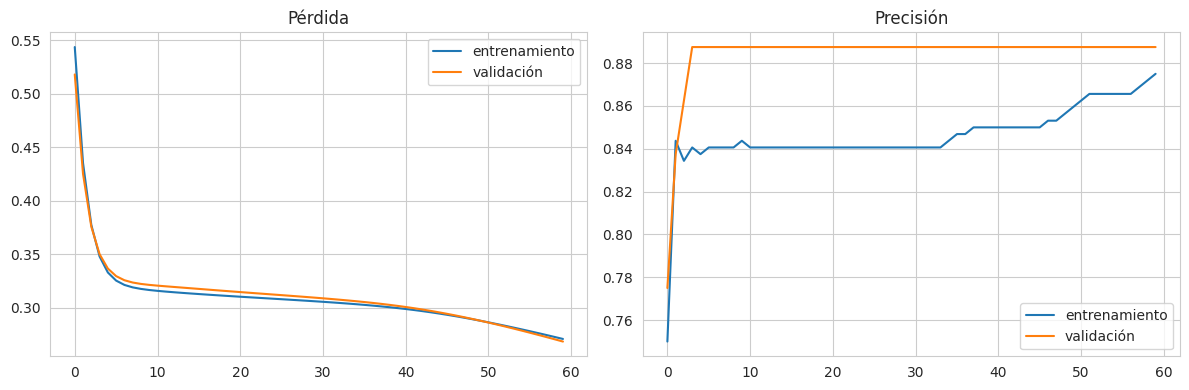

In [12]:
modelo_mlp = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(16, activation="tanh"),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid"),
])
modelo_mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

historial = modelo_mlp.fit(
    X_train_esc, y_train, epochs=60, batch_size=16,
    validation_split=0.2, verbose=0,
)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(historial.history["loss"], label="entrenamiento")
ejes[0].plot(historial.history["val_loss"], label="validación")
ejes[0].set_title("Pérdida"); ejes[0].legend()
ejes[1].plot(historial.history["accuracy"], label="entrenamiento")
ejes[1].plot(historial.history["val_accuracy"], label="validación")
ejes[1].set_title("Precisión"); ejes[1].legend()
plt.tight_layout()
plt.show()

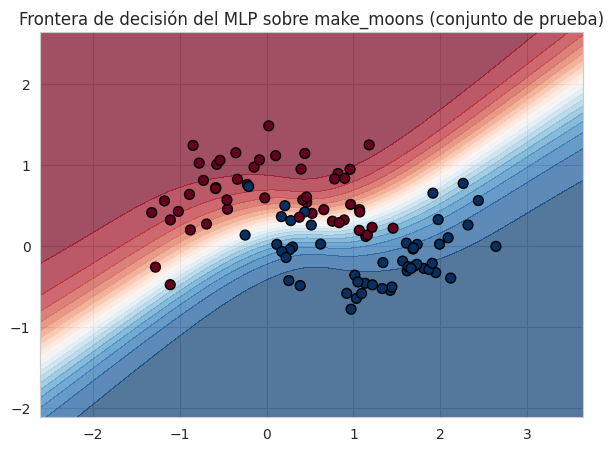

Precisión en test: 0.880


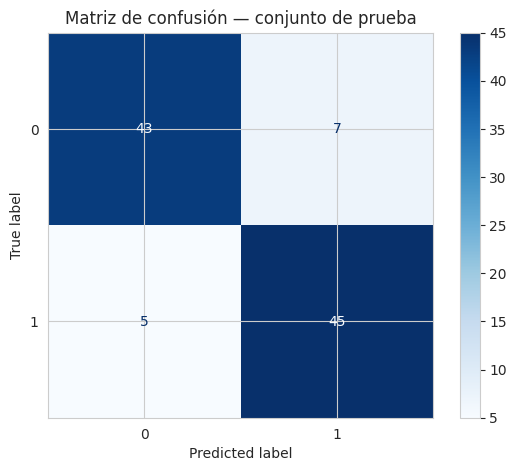

In [13]:
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                      np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = escalador.transform(np.c_[xx.ravel(), yy.ravel()])
Z = modelo_mlp.predict(grid, verbose=0).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.7)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdBu", edgecolor="k", s=50)
plt.title("Frontera de decisión del MLP sobre make_moons (conjunto de prueba)")
plt.show()

perdida_test, precision_test = modelo_mlp.evaluate(X_test_esc, y_test, verbose=0)
print(f"Precisión en test: {precision_test:.3f}")

y_pred = (modelo_mlp.predict(X_test_esc, verbose=0) > 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Matriz de confusión — conjunto de prueba")
plt.show()